# Emotion Analysis


In [ ]:
!pip install tweet-preprocessor 2>/dev/null 1>/dev/null
!pip install emoji
!pip install np_utils
!pip install hazm
!pip install plotly
! pip install --upgrade tensorflow==2.15

  Using cached tensorflow-2.15.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached ml_dtypes-0.2.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached wrapt-1.14.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached tensorflow_estimator-2.15.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [ ]:
import preprocessor as p
import numpy as np
import pandas as pd
from hazm import *
import emoji
import keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU,SimpleRNN
from keras.layers import Dense, Activation, Dropout
from keras.layers import Embedding
from keras.layers import BatchNormalization
import np_utils
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing import text
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
import plotly.graph_objects as go
import plotly.express as px
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
# from kaggle_datasets import KaggleDatasets
import transformers
from transformers import TFAutoModel, AutoTokenizer
from tqdm.notebook import tqdm
from tqdm import tqdm

In [ ]:
print(tf.__version__)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
DATAPATH = "Dataset"

Mounted at /content/drive


# Data preparation  <a class="anchor" id="toc"></a>


In [ ]:
data = pd.read_csv(DATAPATH + "./train.tsv", sep='\t',names=["text", "feeling"])
test_data = pd.read_csv(DATAPATH + "./test.tsv", sep='\t',names=["text", "feeling"])
df_merged = pd.concat([data, test_data], ignore_index=True, sort=False)
data, test_data = train_test_split(df_merged, test_size=0.2)

In [ ]:
data = data[data["feeling"]!="OTHER"]
test_data = test_data[test_data["feeling"]!="OTHER"]

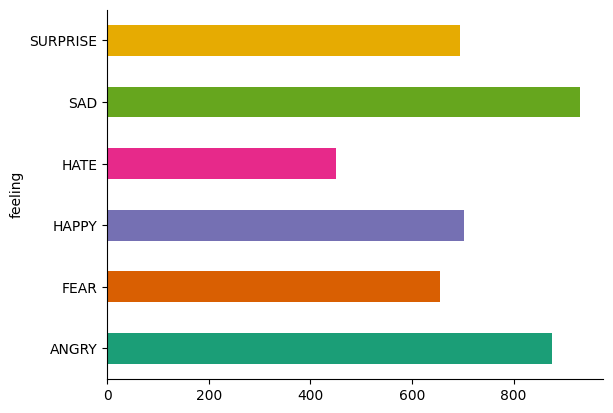

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
test_data

,text,feeling
7250,خشونت زخمی می کند و می شکند؛ التیام هم ندارد.....,SAD
1961,بحران #٣٠سالگي براي من فقط بحران مالي بود ، كه...,SAD
4196,چقدر خشنی تو آخه پسر چشم حسودت کور,SURPRISE
1506,رفتم آرایشگاه موهامو کوتاه کردم. به خانومه گفت...,SAD
4313,اتفاقا خیلی ترسوام,FEAR
...,...,...
5883,از آلبالو و مربای آلبالو و آلبالوپلو متنفرررررم,HATE
6000,خارشونو سگ گایید. مملکتم دقیقا همینجوری قسمت م...,ANGRY
6856,پاسخ شایسته علی انصاریان بازیکن سابق فوتبال به...,HAPPY
2313,این رزمایش سداد رید به اعصابم. یعنی یه ذره امی...,ANGRY


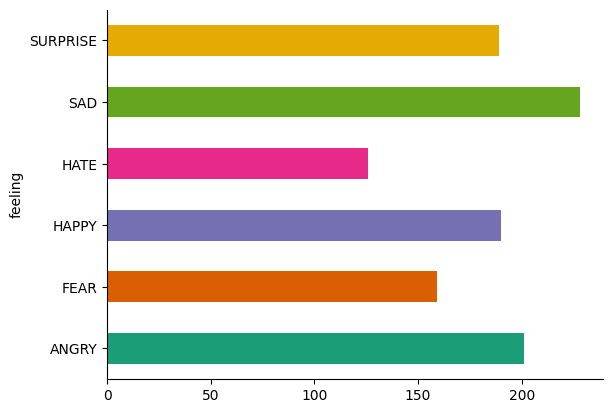

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
test_data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Stop words

In [ ]:
def read_stopwords(file_path):
    with open(file=file_path, mode='r',encoding='utf-8', errors='ignore') as file:
        stopwords = file.readlines()
    stopwords = [word.strip() for word in stopwords]
    return stopwords

def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    filtered_text = ' '.join(filtered_words)
    return filtered_text

stopwords = read_stopwords(DATAPATH + 'stop-words.txt')
tqdm.pandas()
data['text'] = data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))
test_data['text'] = test_data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))

### Deemojize

In [ ]:
import demojize

tqdm.pandas()
data.text = data.text.progress_apply(lambda x : demojize.demojizePersian(x))

ModuleNotFoundError: No module named 'demojize'

In [ ]:
data

,text,feeling
4942,چرا آخه؟,SURPRISE
1244,کاش بفهمید با هر استوری ای ک از تبریک تولد گفت...,ANGRY
5824,صحنه منزجر کننده ایه جدی,HATE
4410,چرا واقعاً,SURPRISE
3913,کسی کوفتم واسه من نمیفرسته,ANGRY
...,...,...
467,سال خیلی عجیب و خوبی بود. خیلی اتفاقا هم افتاد...,SURPRISE
1250,#کارنامه۳۸ساله فقط تلاش جوون و دانشجو نخبه برا...,SAD
340,با چشماش چی داره میگه؟ حرومزاده ها خودتون میخا...,ANGRY
2941,تیمم و تیمم و تیمم و تیمم... این بود تیمت؟ ک.....,ANGRY


### Remove URLS and mentions <a class="anchor" id="dp-r"></a>
<a href="#toc">Back to the table of contents</a>

In [ ]:
import re

def punctuation(val):

    punctuations = '''()-[]{};:'"\,<>./@#$%^&_~'''

    for x in val.lower():
        x.replace("@username", " ")
        x.replace("username", " ")
        if x in punctuations:
            val = val.replace(x, " ")
    return val

def remove_emojis(text):
    # Emoji patterns (with variations)
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def clean_text(val):
    val = remove_emojis(val)
    val = punctuation(val)

    return val

In [ ]:
data["text_cleaned"]=data.text.apply(lambda x : clean_text(x))
test_data["text_cleaned"]=test_data.text.apply(lambda x : clean_text(x))
test_data

,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی میخواد تموم بشه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم ...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشون
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوبه من دومیشو میخوام سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتیه این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمیترسم ممنون اسپرسوی عزیز


In [ ]:
import re
def remove_english_words(text):
    english_pattern = re.compile(r'\b[a-zA-Z]+\b')
    return re.sub(english_pattern, '', text)

data["text_cleaned"]=data.text_cleaned.apply(lambda x : remove_english_words(x))
test_data["text_cleaned"]=test_data.text_cleaned.apply(lambda x : remove_english_words(x))
test_data


,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی میخواد تموم بشه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم ...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشون
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوبه من دومیشو میخوام سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتیه این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمیترسم ممنون اسپرسوی عزیز


In [ ]:

from multiprocessing import Pool, cpu_count
normalizer = Normalizer()
informal_normalizer = InformalNormalizer()
def normalizing(text):
    text = normalizer.normalize(text)
    text = text.replace(',', " ")
    temp_formal = informal_normalizer.normalize(text)
    #print(temp_formal)
    text = ""
    for sentence in temp_formal:
        temp_sent = ""
        for word in sentence:
            if len(word)>1:
                temp_sent += str(word[1])+ " "
            else:
                temp_sent += str(word[0])+ " "
        #print(f"\t-------> {temp_sent}")
        text += temp_sent + " "
    #print(text)
    #print(temp_formal)
    return text

def apply_parallel(df, func):
    num_partitions = cpu_count()  # Number of partitions to split the DataFrame
    num_cores = cpu_count()  # Number of cores to use
    print(num_cores)
    # Split the DataFrame into partitions
    df_split = np.array_split(df, num_partitions)

    # Create a pool of workers
    pool = Pool(num_cores)

    # Apply the function to each partition in parallel
    df = pd.concat(pool.map(func, df_split))

    # Close the pool of workers
    pool.close()
    pool.join()

    return df

# Define the function to be applied to each partition of the DataFrame
def parallel_apply(df):
    return df.progress_apply(normalizing)

# Call the function in parallel
data['text_cleaned'] = apply_parallel(data['text_cleaned'], parallel_apply)
data.to_csv("normalized_formal_data.csv")

test_data['text_cleaned'] = apply_parallel(test_data['text_cleaned'], parallel_apply)
data.to_csv("normalized_formal__test_data.csv")



12


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
100%|██████████| 361/361 [00:00<00:00, 383.76it/s]

100%|██████████| 361/361 [00:00<00:00, 367.74it/s]


100%|██████████| 361/361 [00:00<00:00, 363.50it/s]


12


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
100%|██████████| 89/89 [00:00<00:00, 373.00it/s]

100%|██████████| 89/89 [00:00<00:00, 384.48it/s]

100%|██████████| 89/89 [00:00<00:00, 350.04it/s]

100%|██████████| 89/89 [00:00<00:00, 315.40it/s]


In [ ]:
# clean_text("isn't 💡 adultry @ttt good bad ... ! ? ")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


### Remove empty comments <a class="anchor" id="dp-re"></a>
<a href="#toc">Back to the table of contents</a>

In [ ]:
data = data[data.text_cleaned != ""]
test_data = test_data[test_data.text_cleaned != ""]
test_data

,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی می‌خواهد تمام بشوه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدم خوشگلوخوشاخلاق رو همه دوست دارند ؛ تو اگه ...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم حت...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشان
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوب است من دومیش و می‌خواهم سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتی است این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمی‌ترسم ممنون اسپرسوی عزیز


# Modeling  <a class="anchor" id="m"></a>

### Encoding the data and train test split <a class="anchor" id="m-ed"></a>

In [ ]:
sent_to_id = {"ANGRY":0, "FEAR":1, "HAPPY":2, "HATE":3, "SAD":4, "SURPRISE":5, "OTHER":6}

In [ ]:
selected_columns = ['Anger', 'Fear', 'Happiness', 'Hatred', 'Sadness', 'Wonder', 'Other']
selected_data = data[selected_columns]
data['mean'] = selected_data.mean(axis=1)
normalized_data = data[data['mean'] > 0.5]
std_devs = np.std(selected_data, axis=1)
def create_bitstring(row):
    bitstring = ''.join(['1' if val >= 2 else '0' for val in row])
    return bitstring

normalized_data['bitstring'] = selected_data.apply(lambda row: create_bitstring(row), axis=1)
# Get the maximum values for each row and the corresponding column names
results = []
for i in range(len(normalized_data["mean"])):
    # Find the index of the maximum value in the row
    max_index = selected_data.iloc[i].idxmax()
    results.append(max_index)
normalized_data['sentiment'] = results

data["feeling_id"] = data['feeling'].map(sent_to_id)
test_data["feeling_id"] = test_data['feeling'].map(sent_to_id)
data.shape

(4336, 4)

In [ ]:

weights = {
    ('Anger', 'Hatred'): {'Anger': 0.4, 'Hatred': 0.6},
    ('Happiness', 'Wonder'): {'Happiness': 0.4, 'Wonder': 0.6}
}

# Define a function to get the highest emotion based on the rules
def get_highest_emotion(row):
    max_value = row[['Anger', 'Fear', 'Happiness', 'Hatred', 'Sadness', 'Wonder']].max()
    candidates = row[row == max_value].index.tolist()

    # Check if there's a tie
    if len(candidates) > 1:
        # Check if candidates are in the weighted pairs
        for pair, weight in weights.items():
            if set(pair).issubset(candidates):
                # Select based on the weighted values
                scores = {emotion: row[emotion] * weight[emotion] for emotion in pair}
                return sent_to_id[max(scores, key=scores.get)]
        # If not a special pair, pick randomly
        return sent_to_id[np.random.choice(candidates)]
    else:
        # No tie, return the single highest emotion
        return sent_to_id[candidates[0]]

# Apply the function to each row
normalized_data['Highest_Emotion'] = normalized_data[selected_columns].apply(get_highest_emotion, axis=1)

# Display the result
(normalized_data[['text', 'Highest_Emotion']])


In [ ]:
# data.to_csv("cleaned_dataset.csv")
test_data

,text,feeling,text_cleaned,feeling_id
4612,کی میخواد تموم بشه,SAD,کی می‌خواهد تمام بشوه,4
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدم خوشگلوخوشاخلاق رو همه دوست دارند ؛ تو اگه ...,2
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم حت...,3
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,2
4190,والله با این نوناشون,ANGRY,والله با این نوناشان,0
...,...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,0
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوب است من دومیش و می‌خواهم سفارش بدم,2
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتی است این حساسیت بهاری,0
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمی‌ترسم ممنون اسپرسوی عزیز,2


In [ ]:
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(data.feeling_id)

onehot_encoder = OneHotEncoder(sparse_output=False)

integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# Y = normalized_data.bitstring.apply(lambda x: int(x, 2))
Y = onehot_encoder.fit_transform(integer_encoded)


In [ ]:
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(test_data.feeling_id)

onehot_encoder = OneHotEncoder(sparse_output=False)

integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# Y = normalized_data.bitstring.apply(lambda x: int(x, 2))
test_Y = onehot_encoder.fit_transform(integer_encoded)


In [ ]:
X_train = data.text_cleaned
X_test = test_data.text_cleaned
y_train = Y
y_test = test_Y
X_train.shape


(4336,)